<a href="https://colab.research.google.com/github/mayankchaudhary1010/Internspark-internship-task/blob/main/Zomato_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving zomato.csv to zomato.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [5]:
df = pd.read_csv("zomato.csv")
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [8]:
df.describe()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,15689,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


**Cleaning the data**

In [9]:
df.isnull().sum()

# Drop columns with too many nulls
df.dropna(axis=1, thresh=len(df)*0.5, inplace=True)

# Fill important columns
df['rate'] = df['rate'].fillna('0')
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna('0')

In [11]:
df['rate'] = df['rate'].astype(str)

# Remove '/5' and spaces
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = df['rate'].str.strip()

# Replace invalid values
df['rate'] = df['rate'].replace(['NEW', '-', ''], np.nan)

# Convert to float safely
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [16]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str)

# Remove commas and spaces
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '', regex=False)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.strip()

# Remove currency symbols if present
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace('₹', '', regex=False)

# Replace invalid values
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].replace(['', 'nan'], np.nan)

# Convert safely
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

**EXPLORATORY DATA ANALYSIS**

1. Check the clean data

In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   address                      56235 non-null  object 
 1   name                         56236 non-null  object 
 2   online_order                 56233 non-null  object 
 3   book_table                   56194 non-null  object 
 4   rate                         56252 non-null  float64
 5   votes                        56174 non-null  object 
 6   phone                        54956 non-null  object 
 7   location                     56126 non-null  object 
 8   rest_type                    55914 non-null  object 
 9   cuisines                     56049 non-null  object 
 10  approx_cost(for two people)  51892 non-null  float64
 11  listed_in(type)              51642 non-null  object 
dtypes: float64(2), object(10)
memory usage: 5.2+ MB


,rate,approx_cost(for two people)
count,56252.000000,51892.000000
mean,3.027064,549.854987
std,1.467446,440.139380
min,0.000000,0.000000
25%,3.100000,300.000000
50%,3.600000,400.000000
75%,3.900000,650.000000
max,4.900000,6000.000000


**Rating Distribution**

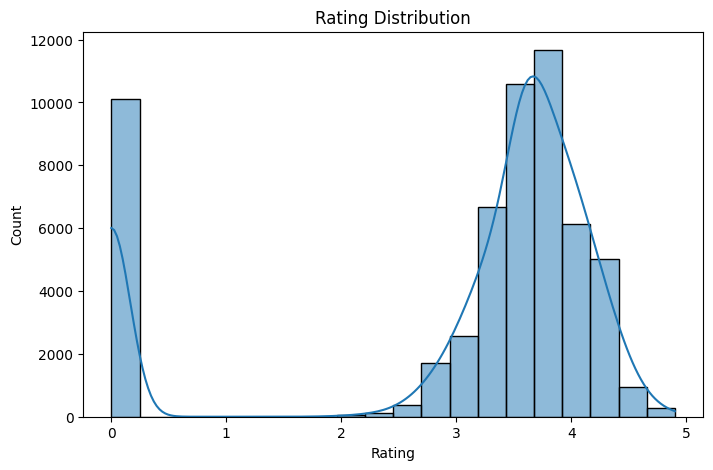

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['rate'], bins=20, kde=True)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

**Top Location (hotspots)**

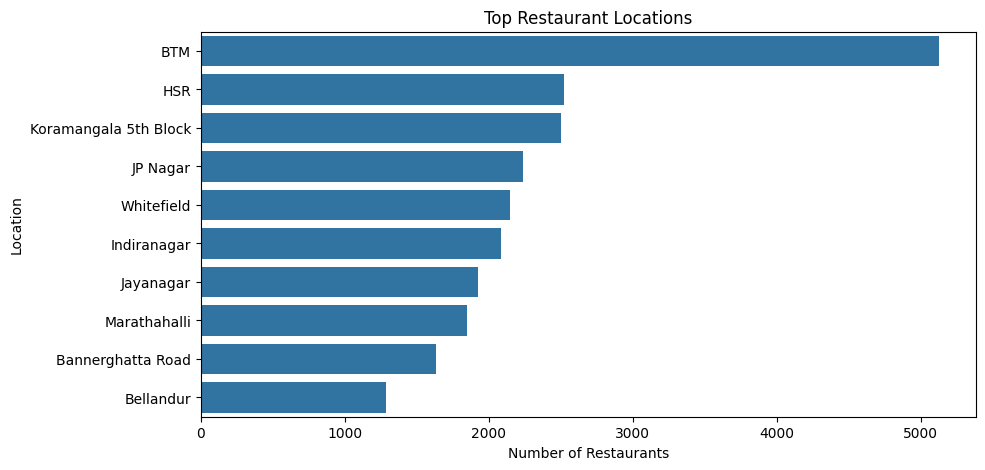

In [19]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top Restaurant Locations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")
plt.show()

**Top Cuisines**

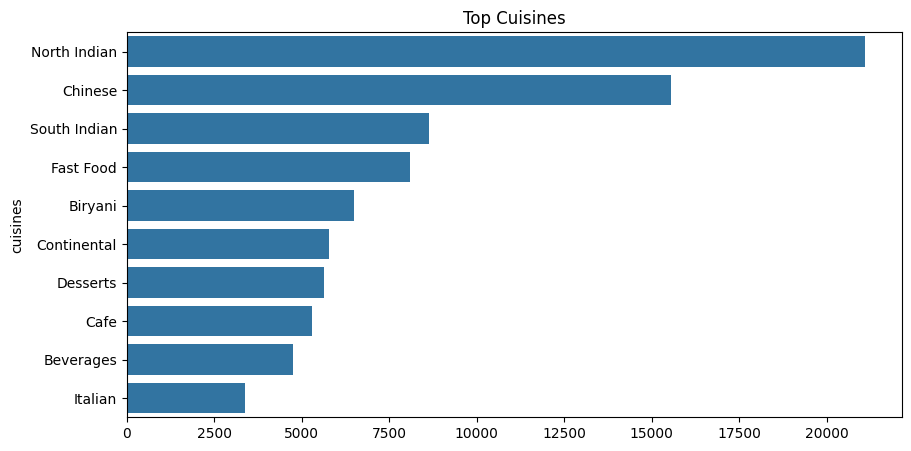

In [20]:
cuisines = df['cuisines'].str.split(', ').explode()

top_cuisines = cuisines.value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top Cuisines")
plt.show()

**Cuisine VS Rating**

In [22]:
# Ensure no null values
df['cuisines'] = df['cuisines'].fillna('Unknown')

# Convert to string (important)
df['cuisines'] = df['cuisines'].astype(str)

# Extract main cuisine safely
df['main_cuisine'] = df['cuisines'].apply(lambda x: x.split(',')[0].strip())

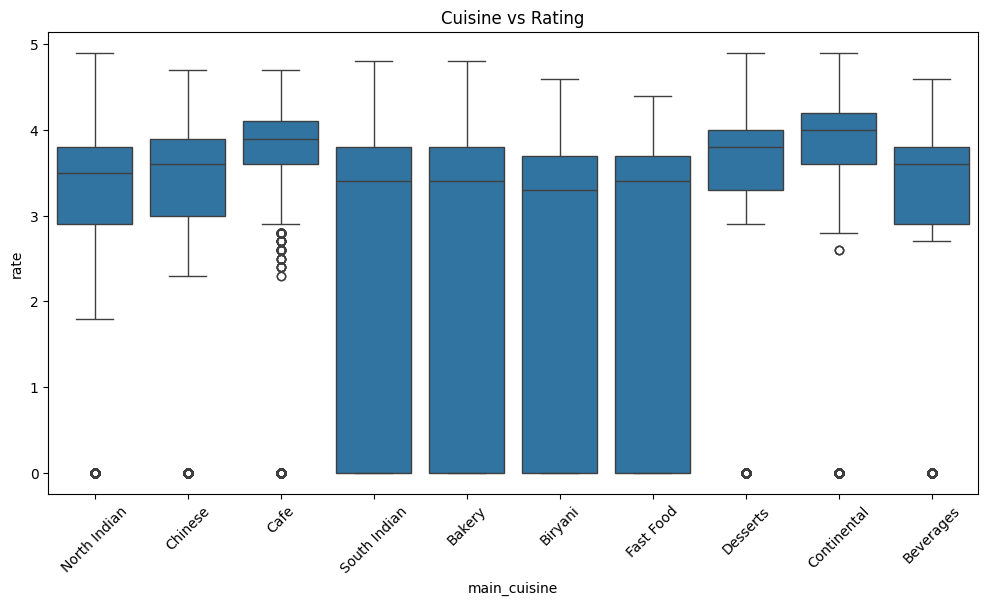

In [23]:
top = df['main_cuisine'].value_counts().head(10).index
filtered = df[df['main_cuisine'].isin(top)]

plt.figure(figsize=(12,6))
sns.boxplot(x='main_cuisine', y='rate', data=filtered)

plt.xticks(rotation=45)
plt.title("Cuisine vs Rating")
plt.show()

Price VS Rating

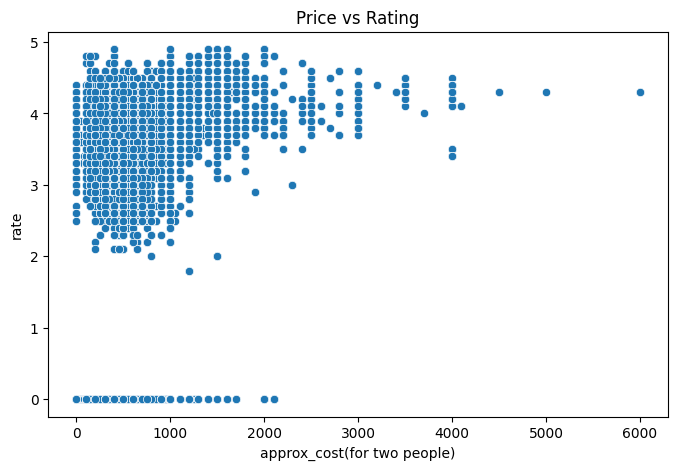

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df)
plt.title("Price vs Rating")
plt.show()

**Corelation heatmap**

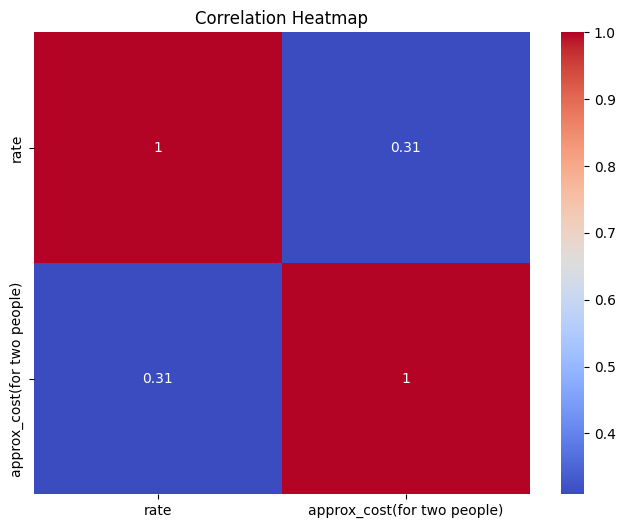

In [25]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Wordcloud**

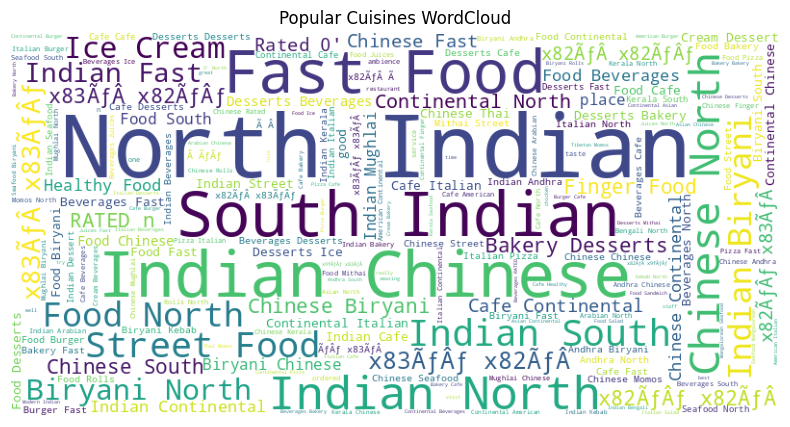

In [26]:
from wordcloud import WordCloud

text = " ".join(df['cuisines'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Popular Cuisines WordCloud")
plt.show()

** Key Insights**
1. Most restaurants fall in 3.5–4.2 rating range.
2. North Indian, Chinese, Fast Food are most popular cuisines.
3. Certain locations have high restaurant density (hotspots).
4. No strong relationship between price and rating.
5. Some cuisines consistently receive better customer ratings.



